# Who will accept the coupon?

## Overview

The goal of this project is to explore a dataset of driving scenarios where users were offered coupons and determine what types of customers are more likely to accept them. By analyzing customer demographics, behavior, and contextual factors, we aim to identify patterns that influence coupon acceptance.

## Context

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

## Data

This data comes from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \\$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\\$20 - $50).

## Data Description

The attributes of this data set include:

1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    
2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical location of the user, destination, and the venue, and we mark the distance between each two places with time of driving. The user can see whether the venue is in the same direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)

3. Coupon attributes
    - time before it expires: 2 hours or one day

## Tools and Libraries

The project uses Python and several common data analysis libraries:

-   Python
-   Pandas
-   NumPy
-   Plotly
-   Seaborn / Matplotlib
-   Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [27]:
original_data = pd.read_csv('data/coupons.csv')
data = original_data.copy()
print(f"Number of entries: {original_data.shape[0]}.")
original_data.head()

Number of entries: 12684.


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


## Missing and Problematic Data

First look for missing data.

In [14]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [15]:
print(original_data['car'].value_counts())

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64


There are 12684 entries, of which 12576 are missing data for the 'car' column. The data present for the car column is not very useful. This column will not be used and dropped.

In [31]:
data = data.drop(columns=['car'])
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='object')

In [32]:
print(data['Bar'].value_counts())
print(data['CoffeeHouse'].value_counts())
print(data['CarryAway'].value_counts())
print(data['RestaurantLessThan20'].value_counts())
print(data['Restaurant20To50'].value_counts())

Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
CoffeeHouse
less1    3385
1~3      3225
never    3179
4~8      1784
gt8      1111
Name: count, dtype: int64
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     304
Name: count, dtype: int64
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     350
Name: count, dtype: int64
Restaurant20To50
less1    6077
1~3      3290
never    2325
4~8       728
gt8       264
Name: count, dtype: int64


The other 5 columns that contain missing data are structured similarly, with values ranging from 'never' to 'gt8'. The entries that contain missing data can either be dropped, or filled in with an assumption. For this study, empty cells will be treated as 'never', and filled in as such.

In [33]:
cols_with_missing = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
data[cols_with_missing] = data[cols_with_missing].fillna('never')
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [56]:
data.sample(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
7677,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,36,Single,...,never,1~3,less1,less1,1,1,0,0,1,0
5391,No Urgent Place,Alone,Sunny,80,10AM,Bar,1d,Female,26,Unmarried partner,...,1~3,1~3,1~3,1~3,1,0,0,0,1,1
12270,Home,Alone,Sunny,80,6PM,Carry out & Take away,2h,Male,26,Single,...,gt8,4~8,4~8,4~8,1,1,0,1,0,1
5020,Home,Alone,Sunny,80,10PM,Restaurant(<20),2h,Female,31,Married partner,...,never,1~3,gt8,1~3,1,0,0,1,0,1
9522,Home,Partner,Sunny,55,10PM,Bar,1d,Male,31,Unmarried partner,...,less1,1~3,1~3,never,1,1,1,0,1,0
2251,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,1~3,less1,never,1,0,0,0,1,0
5095,Home,Alone,Sunny,80,10PM,Restaurant(<20),2h,Male,21,Single,...,1~3,4~8,1~3,less1,1,0,0,1,0,0
12522,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,never,1~3,never,1,1,1,0,1,0
266,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,31,Married partner,...,less1,1~3,less1,less1,1,1,0,0,1,1
11612,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Female,21,Single,...,never,less1,never,never,1,0,0,1,0,0


The Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 columns are really category columns. Changing them to a panda's Categorical type will allow the order to be specified, which will be real useful for graphs and analysis. The same issue exists with the age column, where the column is really categories and not just a number.

In [64]:
data['coupon'].value_counts()

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64

In [63]:
coupon_order = ['Bar','Coffee House','Carry out & Take away','Restaurant(<20)','Restaurant(20-50)']
data['coupon'] = pd.Categorical(data['coupon'], categories=coupon_order, ordered=True)
freq_order = ['never','less1','1~3','4~8','gt8']
data['Bar'] = pd.Categorical(data['Bar'], categories=freq_order, ordered=True)
data['CoffeeHouse'] = pd.Categorical(data['CoffeeHouse'], categories=freq_order, ordered=True)
data['CarryAway'] = pd.Categorical(data['CarryAway'], categories=freq_order, ordered=True)
data['RestaurantLessThan20'] = pd.Categorical(data['RestaurantLessThan20'], categories=freq_order, ordered=True)
data['Restaurant20To50'] = pd.Categorical(data['Restaurant20To50'], categories=freq_order, ordered=True)
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
data['age'] = pd.Categorical(data['age'], categories=age_order, ordered=True)

## General Coupon Acceptance Analysis

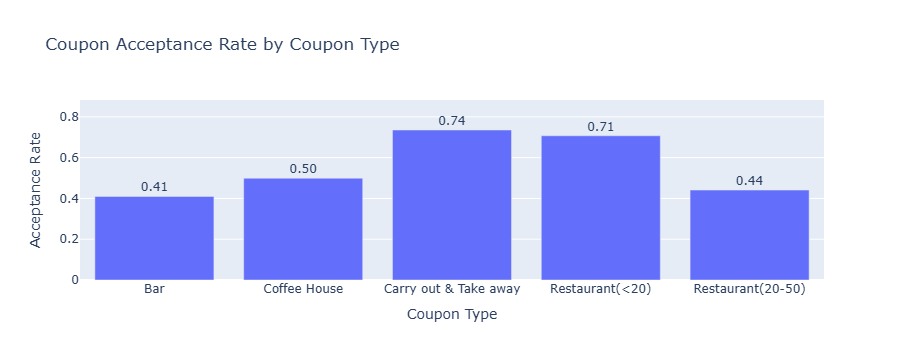

In [67]:
coupon_acceptance = data.groupby('coupon', observed=True)['Y'].mean().reset_index()
fig = px.bar(
    coupon_acceptance,
    x='coupon',
    y='Y',
    text='Y',
    title='Coupon Acceptance Rate by Coupon Type',
    labels={
        'coupon': 'Coupon Type',
        'Y': 'Acceptance Rate'
    }
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_yaxes(range=[0, coupon_acceptance['Y'].max() * 1.2])
fig.show()

This chart compares acceptance rates across coupon categories. Coffee house and close-by restaurant coupons have higher acceptance rates, while bar coupons have lower acceptance overall, suggesting behavioral targeting may be more important for bar and coffee house coupons.

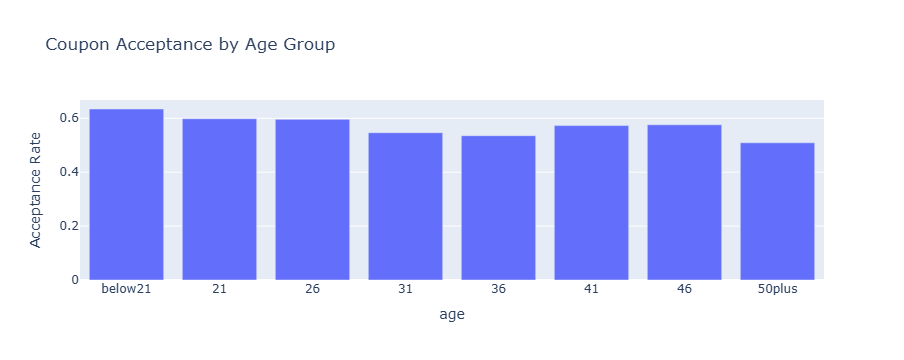

In [79]:
age_acceptance = data.groupby('age', observed=True)['Y'].mean().sort_values()
fig = px.bar(
    age_acceptance.reset_index(),
    x='age',
    y='Y',
    title='Coupon Acceptance by Age Group',
    category_orders={'age': age_order},
    labels={'Y':'Acceptance Rate'}
)
fig.show()

This chart examines overall coupon acceptance by age group. It shows a slight tendency for younger age groups to accept coupons more frequently. However, this relationship appears weak on its own. To better understand how age influences coupon acceptance, behavioral and contextual factors, such as driving situation or past visiting habits, need to be considered alongside age.

## Bar Coupon Acceptance Analysis

In [57]:
bar_data = data[data['coupon'] == 'Bar'].copy()

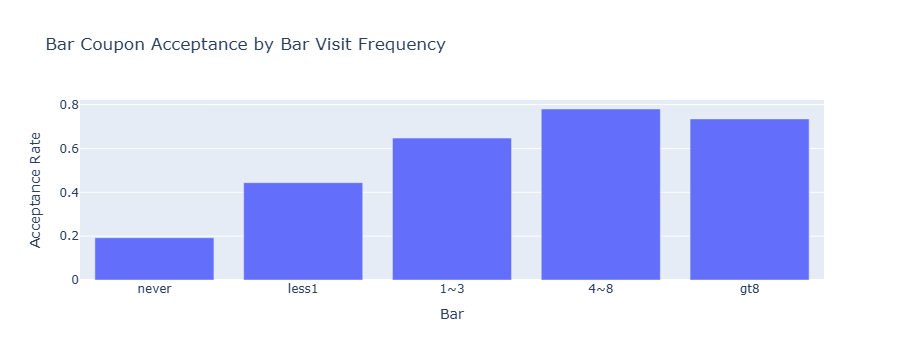

Acceptance rate of bar coupons for persons visiting bars less than once a month: 29.35%
Acceptance rate of bar coupons for persons visiting bars more than once a month: 68.79%


In [86]:
bar_freq_acceptance = bar_data.groupby('Bar', observed=True)['Y'].mean().reset_index()
fig = px.bar(
    bar_freq_acceptance,
    x='Bar',
    y='Y',
    title='Bar Coupon Acceptance by Bar Visit Frequency',
    labels={'Y':'Acceptance Rate'}
)
fig.show()
bar_less_than_once = bar_data[bar_data['Bar'].isin(['never', 'less1'])]
bar_over_once = bar_data[bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])]
print(f"Acceptance rate of bar coupons for persons visiting bars less than once a month: {bar_less_than_once['Y'].mean():.2%}")
print(f"Acceptance rate of bar coupons for persons visiting bars more than once a month: {bar_over_once['Y'].mean():.2%}")

When analyzing bar coupon acceptance, bar visitation frequency appears to be a strong predictor of whether a coupon will be accepted. Drivers who visit bars more than once per month accept bar coupons at more than twice the rate of those who visit less frequently. This suggests that targeting bar coupons toward customers who already visit bars regularly would likely be a more effective promotional strategy.

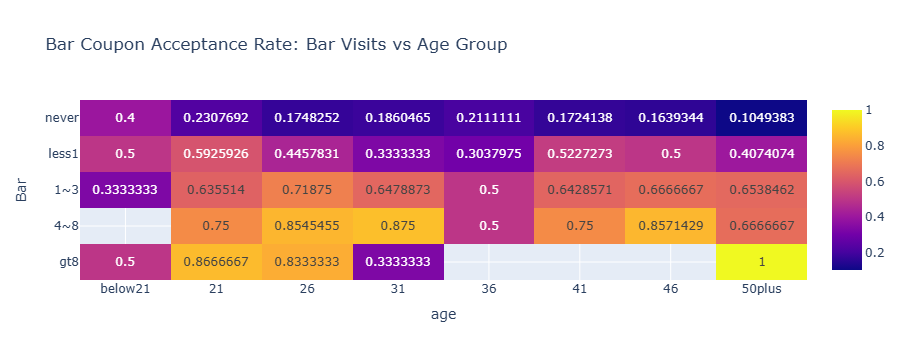

In [89]:
heatmap_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='mean',
    observed=True
)
fig = px.imshow(
    heatmap_data,
    text_auto=True,
    aspect="auto",
    title="Bar Coupon Acceptance Rate: Bar Visits vs Age Group"
)
fig.show()

This heatmap illustrates bar coupon acceptance rates across age groups and bar visitation frequency. The results show that coupon acceptance generally increases as bar visitation frequency increases, regardless of age group. While some age-related variation exists, behavioral factors such as bar visitation appear to be a stronger predictor of coupon acceptance than demographics alone. Frequent bar-goers, particularly in younger to middle-aged segments, represent the most responsive target group for bar-related promotions. There is a 100% acceptance for the segment of greater than 8 frequency and age of 50plus, that should be investigated.

In [91]:
bar_data.groupby(['Bar','age'],observed=True)['Y'].agg(['mean','count'])

mean  count
Bar   age                     
never below21  0.400000     65
      21       0.230769    143
      26       0.174825    143
      31       0.186047    129
      36       0.211111     90
      41       0.172414     58
      46       0.163934     61
      50plus   0.104938    162
less1 below21  0.500000     12
      21       0.592593    108
      26       0.445783     83
      31       0.333333    114
      36       0.303797     79
      41       0.522727     88
      46       0.500000     32
      50plus   0.407407     54
1~3   below21  0.333333      6
      21       0.635514    107
      26       0.718750     96
      31       0.647887     71
      36       0.500000     28
      41       0.642857     28
      46       0.666667      9
      50plus   0.653846     52
4~8   21       0.750000     44
      26       0.854545     55
      31       0.875000     16
      36       0.500000     12
      41       0.750000      4
      46       0.857143      7
      50plus   0.666667     12
gt8   below21  0.500000      4
      21       0.866667     15
      26       0.833333     18
      31       0.333333      9
      50plus   1.000000      3

From the above counts, there were only 3 entries for the segment corresponding to greater than 8 visits and 50 or over age. This segment contains very few observations, suggesting that the result may be driven by a small sample size rather than a reliable trend.

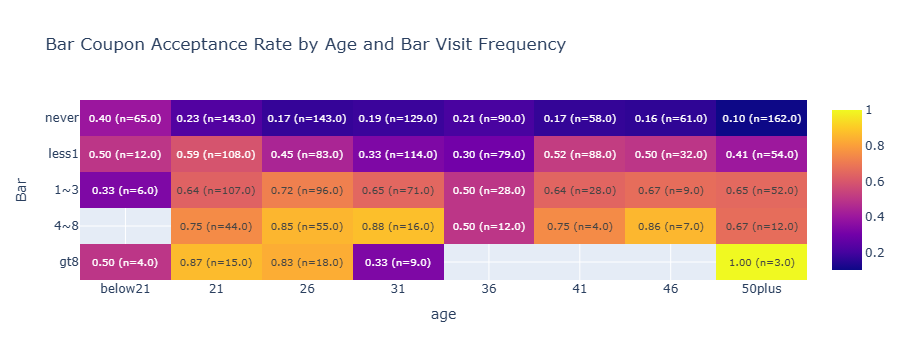

In [94]:
bar_heatmap_rate_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='mean',
    observed=True
)

bar_heatmap_count_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='count',
    observed=True
)

bar_heatmap_annotation = bar_heatmap_rate_data.copy().astype(object)

for r in bar_heatmap_rate_data.index:
    for c in bar_heatmap_rate_data.columns:
        rate = bar_heatmap_rate_data.loc[r, c]
        count = bar_heatmap_count_data.loc[r, c]
        if pd.notna(rate):
            bar_heatmap_annotation.loc[r, c] = f"{rate:.2f}\n(n={count})"
        else:
            bar_heatmap_annotation.loc[r, c] = ""

fig = px.imshow(
    bar_heatmap_rate_data,
    text_auto=False,
    aspect="auto",
    title="Bar Coupon Acceptance Rate by Age and Bar Visit Frequency"
)

fig.update_traces(text=bar_heatmap_annotation.values, texttemplate="%{text}")

fig.show()

This heatmap combines both acceptance rate and sample size in a single visualization. It allows us to see not only where coupon acceptance is highest, but also whether those results are supported by a meaningful number of observations. This helps distinguish statistically meaningful patterns from potential outliers caused by small sample sizes.

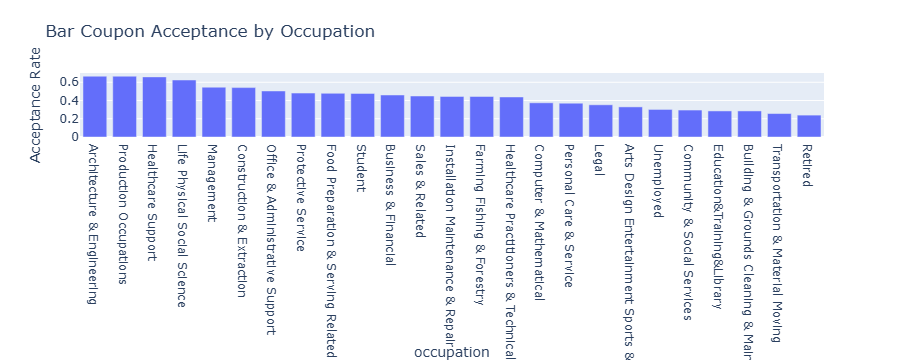

In [95]:
bar_occupation_acceptance = (
    bar_data.groupby('occupation', observed=True)['Y']
    .mean()
    .sort_values(ascending=False)
)
fig = px.bar(
    bar_occupation_acceptance.reset_index(),
    x='occupation',
    y='Y',
    title='Bar Coupon Acceptance by Occupation',
    labels={'Y': 'Acceptance Rate'}
)
fig.show()

In [97]:
#bar_data['occupation'].value_counts()
bar_top_3_occupation_list = ['Architecture & Engineering','Production Occupations','Healthcare Support']
bar_bottom_3_occupation_list = ['Building & Grounds Cleaning & Maintenance','Transportation & Material Moving','Retired']
bar_top_3_occupation = bar_data[bar_data['occupation'].isin(bar_top_3_occupation_list)]
bar_bottom_3_occupation = bar_data[bar_data['occupation'].isin(bar_bottom_3_occupation_list)]
print(f"Acceptance rate of bar coupons for persons in top 3 occupations: {bar_top_3_occupation['Y'].mean():.2%}")
print(f"Acceptance rate of bar coupons for persons in bottom 3 occupations: {bar_bottom_3_occupation['Y'].mean():.2%}")

Acceptance rate of bar coupons for persons in top 3 occupations: 66.29%
Acceptance rate of bar coupons for persons in bottom 3 occupations: 24.79%


This graph shows that occupation may also influence bar coupon acceptance. The top three occupations exhibit acceptance rates more than twice as high as those of the bottom three occupations, suggesting that occupational differences may play a role in the effectiveness of bar coupon promotions.

### Bar Coupon Acceptance Summary

Analysis of bar coupon acceptance suggests that behavioral factors play the strongest role in determining whether a coupon will be accepted. Drivers who visit bars more than once per month accept bar coupons at more than twice the rate of those who visit bars less frequently, indicating that past visitation behavior is a strong predictor of responsiveness. Age and occupation also show some variation in acceptance rates, though their influence appears secondary compared to bar visitation frequency. Additionally, certain segments with extremely high acceptance rates were found to have very small sample sizes, suggesting those results should be interpreted cautiously. Overall, the most effective targeting strategy for bar coupons would focus on customers who already visit bars regularly, particularly within younger to middle-aged segments where acceptance rates tend to be higher.